## Section 1 — Setup [R]

In [ ]:
# Load packages
# DBI + RMariaDB: database connection and query execution
# dplyr + tidyr: data manipulation
# ggplot2 + scales: visualisation # nolint: commented_code_linter.
# here: resolve project-root-relative paths regardless of working directory
suppressPackageStartupMessages({
  library(DBI)
  library(RMariaDB)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(scales)
  library(here)
  library(dotenv)
})

load_dot_env(here(".env"))

# bigint = "integer" forces MySQL COUNT() results from integer64 to standard
# R integers. integer64 is incompatible with scales formatting functions.
con <- dbConnect(
  RMariaDB::MariaDB(),
  host     = Sys.getenv("DB_HOST"),
  port     = as.integer(Sys.getenv("DB_PORT")),
  dbname   = Sys.getenv("DB_NAME"),
  user     = Sys.getenv("DB_USER"),
  password = Sys.getenv("DB_PASSWORD"),
  bigint   = "integer"
)

message("Connected to platos_pizza warehouse.")

Connected to platos_pizza warehouse.



In [ ]:
# Shared ggplot2 theme — consistent with operational_analysis.R
theme_platos <- function() {
  theme_minimal(base_size = 12) + # nolint: object_usage_linter.
    theme( # nolint: object_usage_linter.
      plot.title       = element_text(face = "bold", size = 14), # nolint: object_usage_linter, line_length_linter.
      plot.subtitle    = element_text(size = 10, colour = "#555555"),
      plot.caption     = element_text(size = 8,  colour = "#888888"),
      panel.grid.minor = element_blank(), # nolint: object_usage_linter, line_length_linter.
      axis.title       = element_text(size = 10),
      legend.position  = "bottom"
    )
}

OUTPUT_DIR <- here("reports", "charts")
if (!dir.exists(OUTPUT_DIR)) dir.create(OUTPUT_DIR, recursive = TRUE)

save_chart <- function(plot, filename, width = 8, height = 5) {
  ggsave(file.path(OUTPUT_DIR, filename), plot = plot, # nolint: object_usage_linter, line_length_linter.
         width = width, height = height, dpi = 150)
  message("Saved: ", filename)
}

## Section 2 — Basket Analysis: Co-occurrence and Lift [R]

**Why this is done in R rather than SQL:**  
Lift calculation requires a pairwise self-join across all order-item combinations. MySQL cannot
reopen a temporary table within the same query, and a direct self-join on `fact_orders` times out.
R loads the data into memory and performs the join without these constraints. The analytical
logic is identical — only the execution environment differs.

**Lift definition:**  
`lift(A, B) = P(A and B in same order) / (P(A) * P(B))`  
- `lift = 1.0`: co-occur exactly as chance predicts  
- `lift > 1.0`: appear together more than chance — potential bundle opportunity  
- `lift < 1.0`: appear together less than chance — worth investigating for cannibalisation

In [ ]:
# Pull the order-item table from the warehouse.
# We deduplicate to one row per order-pizza_type combination.
# Deduplication is critical — without it, an order containing
# three Pepperoni pizzas would inflate the co-occurrence count.
order_items <- dbGetQuery(con, "
  SELECT DISTINCT
    fo.order_id,
    fo.pizza_type_id,
    dpt.name     AS pizza_name,
    dpt.category
  FROM fact_orders fo
  JOIN dim_pizza_type dpt ON fo.pizza_type_id = dpt.pizza_type_id
") |>
  distinct(order_id, pizza_type_id, .keep_all = TRUE)  # belt-and-braces dedup

n_orders <- n_distinct(order_items$order_id)

item_counts <- order_items |>
  group_by(pizza_type_id, pizza_name, category) |>
  summarise(orders_with_item = n_distinct(order_id), .groups = "drop")

message(sprintf("Loaded %d distinct order-item pairs across %d orders.",
                nrow(order_items), n_orders))
glimpse(item_counts)

Loaded 47316 distinct order-item pairs across 21350 orders.



Rows: 32
Columns: 4
$ pizza_type_id    <chr> "bbq_ckn", "big_meat", "brie_carre", "calabrese", "ca…
$ pizza_name       <chr> "The Barbecue Chicken Pizza", "The Big Meat Pizza", "…
$ category         <chr> "Chicken", "Classic", "Supreme", "Supreme", "Chicken"…
$ orders_with_item <int> 2273, 1811, 480, 918, 2197, 967, 938, 2329, 1359, 180…


In [ ]:
# Pairwise co-occurrence using an inner join on order_id.
# The filter pizza_name_a < pizza_name_b ensures each pair appears once.
# Without this, Pepperoni-Hawaiian and Hawaiian-Pepperoni would both appear,
# doubling the count and halving the lift score.
pairs <- order_items |>
  inner_join(
    order_items |> select(order_id, pizza_type_id_b = pizza_type_id,
                          pizza_name_b = pizza_name, category_b = category),
    by = "order_id",
    relationship = "many-to-many"
  ) |>
  filter(pizza_name < pizza_name_b) |>
  group_by(pizza_type_id, pizza_name, category,
           pizza_type_id_b, pizza_name_b, category_b) |>
  summarise(orders_with_both = n_distinct(order_id), .groups = "drop")

message(sprintf("%d unique pizza-type pairs found.", nrow(pairs)))

496 unique pizza-type pairs found.



In [ ]:
# Compute lift scores.
# Minimum threshold of 50 co-occurrences excludes rare pairs that produce
# mathematically valid but practically meaningless lift values.
lift_scores <- pairs |>
  left_join(item_counts |> select(pizza_type_id, orders_a = orders_with_item),
            by = "pizza_type_id") |>
  left_join(item_counts |> select(pizza_type_id_b = pizza_type_id,
                                   orders_b = orders_with_item),
            by = "pizza_type_id_b") |>
  mutate(
    lift = round(orders_with_both * n_orders / (orders_a * orders_b), 3)
  ) |>
  filter(orders_with_both >= 50) |>
  arrange(desc(lift))

message(sprintf("%d pairs passed the 50-order threshold.", nrow(lift_scores)))
head(lift_scores |> select(pizza_name, pizza_name_b, orders_with_both, lift), 10)

452 pairs passed the 50-order threshold.



pizza_name,pizza_name_b,orders_with_both,lift
<chr>,<chr>,<int>,<dbl>
The Italian Vegetables Pizza,"The Pepperoni, Mushroom, and Peppers Pizza",88,1.500
The Italian Vegetables Pizza,The Soppressata Pizza,60,1.430
The Greek Pizza,The Mediterranean Pizza,82,1.410
The Chicken Pesto Pizza,The Vegetables + Vegetables Pizza,90,1.400
The Four Cheese Pizza,The Italian Vegetables Pizza,111,1.376
The Chicken Pesto Pizza,The Mediterranean Pizza,55,1.373
The Calabrese Pizza,The Italian Vegetables Pizza,56,1.368
The Spinach Pesto Pizza,The Spinach Supreme Pizza,55,1.354
The Brie Carre Pizza,The Sicilian Pizza,55,1.344


Saved: 10_top_complementary_pairs.png



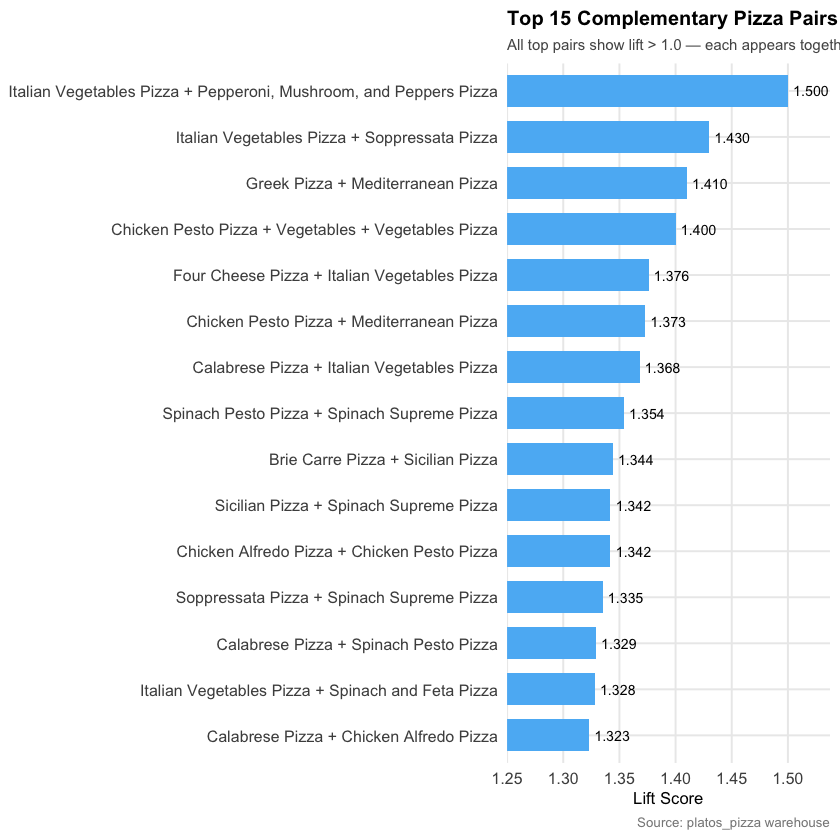

In [ ]:
# Chart: Top 15 complementary pairs by lift score.
# These are the natural bundle candidates the restaurant could promote.
top_pairs <- lift_scores |>
  slice_max(lift, n = 15) |>
  mutate(
    pair_label = paste(
      gsub("^The ", "", pizza_name), "+",
      gsub("^The ", "", pizza_name_b)
    ),
    pair_label = factor(pair_label, levels = pair_label[order(lift)])
  )

x_min <- floor(min(top_pairs$lift) * 10) / 10 - 0.05

top_pairs_plot <- top_pairs |>
  ggplot(aes(x = lift, y = pair_label)) +
  geom_col(fill = "#5BB8F5", width = 0.7) +
  geom_text(aes(label = sprintf("%.3f", lift)), hjust = -0.15, size = 3) +
  scale_x_continuous(expand = expansion(mult = c(0, 0.15))) +
  coord_cartesian(xlim = c(x_min, NA)) +
  labs(
    title    = "Top 15 Complementary Pizza Pairs by Lift Score",
    subtitle = "All top pairs show lift > 1.0 — each appears together more often than chance predicts.",
    x        = "Lift Score",
    y        = NULL,
    caption  = "Source: platos_pizza warehouse"
  ) +
  theme_platos() +
  theme(plot.title = element_text(size = 12),
        plot.subtitle = element_text(size = 9))

top_pairs_plot
save_chart(top_pairs_plot, "10_top_complementary_pairs.png", width = 11, height = 6)

## Section 3 — Cannibalisation Screening [R]

**Important caveat:** Low lift or negative correlation between similar items does not prove
cannibalisation. Two items could simply appeal to different customer segments. Proving true
cannibalisation requires a controlled experiment — remove one item and observe whether the
other's sales rise. This section produces a **shortlist of candidates to investigate**, not verdicts.

Two independent signals are used:  
1. **Within-category lift** — do similar items appear together less than chance?  
2. **Daily sales correlation** — when one item sells well, does the other sell less?

In [ ]:
# Within-category lift scores.
# Restricted to pairs sharing the same category.
# Minimum threshold reduced to 30 because within-category pairs are rarer.
within_category_lift <- lift_scores |>
  filter(category == category_b, orders_with_both >= 30) |>
  arrange(category, lift)

# Items with the lowest within-category lift are the primary candidates.
# A lift below 1.0 means the pair appears together LESS than chance predicts.
within_category_lift |>
  select(category, pizza_name, pizza_name_b, orders_with_both, lift) |>
  filter(lift < 1.0)

category,pizza_name,pizza_name_b,orders_with_both,lift
<chr>,<chr>,<chr>,<int>,<dbl>
Classic,The Italian Capocollo Pizza,"The Pepperoni, Mushroom, and Peppers Pizza",80,0.940
Classic,The Pepperoni Pizza,"The Pepperoni, Mushroom, and Peppers Pizza",133,0.947
Classic,The Greek Pizza,The Napolitana Pizza,86,0.949
Classic,The Hawaiian Pizza,The Italian Capocollo Pizza,141,0.957
Classic,The Greek Pizza,The Italian Capocollo Pizza,87,0.989
Classic,The Big Meat Pizza,The Classic Deluxe Pizza,197,0.997
Supreme,The Spicy Italian Pizza,The Spinach Supreme Pizza,76,0.970
Supreme,The Italian Supreme Pizza,The Spinach Supreme Pizza,75,0.974
Veggie,The Spinach and Feta Pizza,The Vegetables + Vegetables Pizza,88,0.916


In [ ]:
# Daily sales correlation between same-category item pairs.
# A negative correlation means when one item sells well, the other tends to sell less. # nolint: line_length_linter.
# Combined with low lift, this is a stronger cannibalisation signal.
daily_sales <- dbGetQuery(con, "
  SELECT
    fo.date_id,
    dpt.pizza_type_id,
    dpt.name     AS pizza_name,
    dpt.category,
    SUM(fo.quantity) AS daily_qty
  FROM fact_orders fo
  JOIN dim_pizza_type dpt ON fo.pizza_type_id = dpt.pizza_type_id
  GROUP BY fo.date_id, dpt.pizza_type_id, dpt.name, dpt.category
")

# Self-join on date to build daily pairs, then compute Pearson correlation.
# Only pairs with at least 100 shared trading days are included —
# below that threshold the correlation estimate is too noisy to act on.
daily_corr <- daily_sales |>
  inner_join(
    daily_sales |> rename(pizza_type_id_b = pizza_type_id,
                          pizza_name_b    = pizza_name,
                          category_b      = category,
                          daily_qty_b     = daily_qty),
    by = "date_id",
    relationship = "many-to-many"
  ) |>
  filter(category == category_b, pizza_name < pizza_name_b) |>
  group_by(category, pizza_name, pizza_name_b) |>
  filter(n() >= 100) |>
  summarise(
    shared_days = n(),
    correlation = round(cor(daily_qty, daily_qty_b, method = "pearson"), 3),
    .groups = "drop"
  ) |>
  arrange(category, correlation)

message("Daily correlation computed for ", nrow(daily_corr), " within-category pairs.")
head(daily_corr, 15)

Daily correlation computed for 115 within-category pairs.



category,pizza_name,pizza_name_b,shared_days,correlation
<chr>,<chr>,<chr>,<int>,<dbl>
Chicken,The Barbecue Chicken Pizza,The Chicken Alfredo Pizza,329,0.030
Chicken,The Chicken Pesto Pizza,The Southwest Chicken Pizza,325,0.035
Chicken,The Barbecue Chicken Pizza,The Thai Chicken Pizza,358,0.045
Chicken,The Barbecue Chicken Pizza,The Chicken Pesto Pizza,326,0.057
Chicken,The Chicken Alfredo Pizza,The Southwest Chicken Pizza,328,0.064
Chicken,The Barbecue Chicken Pizza,The California Chicken Pizza,358,0.074
Chicken,The Barbecue Chicken Pizza,The Southwest Chicken Pizza,357,0.075
Chicken,The California Chicken Pizza,The Thai Chicken Pizza,358,0.085
Chicken,The Chicken Alfredo Pizza,The Thai Chicken Pizza,329,0.092


In [ ]:
# Flag pairs that show BOTH low lift AND negative/near-zero correlation.
# These are the strongest cannibalisation candidates.
candidates <- within_category_lift |>
  select(category, pizza_name, pizza_name_b, lift) |>
  inner_join(
    daily_corr |> select(category, pizza_name, pizza_name_b, correlation),
    by = c("category", "pizza_name", "pizza_name_b")
  ) |>
  filter(lift < 1.0 | correlation < 0.05) |>
  arrange(lift, correlation)

message(sprintf("%d cannibalisation candidates flagged.", nrow(candidates)))
print(candidates)

36 cannibalisation candidates flagged.



# A tibble: 36 × 5
   category pizza_name                  pizza_name_b            lift correlation
   <chr>    <chr>                       <chr>                  <dbl>       <dbl>
 1 Veggie   The Spinach and Feta Pizza  The Vegetables + Vege… 0.916       0.146
 2 Veggie   The Five Cheese Pizza       The Italian Vegetable… 0.924       0.09 
 3 Classic  The Italian Capocollo Pizza The Pepperoni, Mushro… 0.94        0.182
 4 Veggie   The Spinach Pesto Pizza     The Vegetables + Vege… 0.942       0.08 
 5 Classic  The Pepperoni Pizza         The Pepperoni, Mushro… 0.947       0.056
 6 Classic  The Greek Pizza             The Napolitana Pizza   0.949       0.06 
 7 Veggie   The Mexicana Pizza          The Spinach and Feta … 0.95        0.06 
 8 Classic  The Hawaiian Pizza          The Italian Capocollo… 0.957       0.027
 9 Veggie   The Mexicana Pizza          The Vegetables + Vege… 0.962       0.106
10 Supreme  The Spicy Italian Pizza     The Spinach Supreme P… 0.97        0.068
# ℹ 26 mo

## Section 4 — Seasonal Decomposition [R]

Seasonal decomposition separates a time series into three components:  
- **Trend** — the underlying direction of demand over time  
- **Seasonality** — repeating patterns (weekly, monthly)  
- **Residual** — unexplained variation after trend and seasonality are removed  

This section uses R's `stl()` function (Seasonal and Trend decomposition using Loess).
The output informs Prophet — if trend is flat, a simpler model may suffice.
If seasonality is strong, Prophet's seasonal components will be important.

In [ ]:
# Pull daily time series from the warehouse.
daily_ts <- dbGetQuery(con, "
  SELECT
    fo.date_id,
    COUNT(DISTINCT fo.order_id) AS total_orders
  FROM fact_orders fo
  GROUP BY fo.date_id
  ORDER BY fo.date_id
")

daily_ts$date_id <- as.Date(daily_ts$date_id)

# Gap check: are there missing trading days?
# stl() requires a complete, evenly-spaced series.
# Missing days must be filled with NA or imputed before decomposition.
full_calendar <- data.frame(
  date_id = seq(min(daily_ts$date_id), max(daily_ts$date_id), by = "day")
)
missing_days <- anti_join(full_calendar, daily_ts, by = "date_id")
message(sprintf("%d missing days in the trading calendar.", nrow(missing_days)))
if (nrow(missing_days) > 0) print(missing_days)

7 missing days in the trading calendar.



     date_id
1 2015-09-24
2 2015-09-25
3 2015-10-05
4 2015-10-12
5 2015-10-19
6 2015-10-26
7 2015-12-25


In [ ]:
# Fill missing days with the weekly median for that day of week.
# This is a conservative imputation — it does not invent demand,
# it substitutes a plausible value so the series is complete.
daily_complete <- full_calendar |>
  left_join(daily_ts, by = "date_id") |>
  mutate(
    day_of_week = weekdays(date_id),
    is_imputed  = is.na(total_orders)
  )

dow_medians <- daily_complete |>
  filter(!is_imputed) |>
  group_by(day_of_week) |>
  summarise(median_orders = median(total_orders), .groups = "drop")

daily_complete <- daily_complete |>
  left_join(dow_medians, by = "day_of_week") |>
  mutate(total_orders = if_else(is_imputed, as.integer(round(median_orders)),
                                total_orders)) |>
  select(date_id, total_orders, is_imputed)

message(sprintf("%d days imputed. Series length: %d days.",
                sum(daily_complete$is_imputed), nrow(daily_complete)))

7 days imputed. Series length: 365 days.



In [ ]:
# STL decomposition.
# s.window = "periodic" assumes a stable weekly seasonal pattern —
# appropriate here because the Kruskal-Wallis test in Notebook 02
# confirmed day-of-week effects are statistically significant.
ts_obj <- ts(daily_complete$total_orders,
             frequency = 7)  # weekly seasonality

stl_result <- stl(ts_obj, s.window = "periodic", robust = TRUE)

# Extract components into a data frame for plotting.
decomp_df <- data.frame(
  date_id    = daily_complete$date_id,
  observed   = daily_complete$total_orders,
  trend      = as.numeric(stl_result$time.series[, "trend"]),
  seasonal   = as.numeric(stl_result$time.series[, "seasonal"]),
  remainder  = as.numeric(stl_result$time.series[, "remainder"])
)

message("Decomposition complete. Trend range: ",
        round(min(decomp_df$trend), 1), " to ",
        round(max(decomp_df$trend), 1), " orders/day.")
summary(decomp_df)

Decomposition complete. Trend range: 25.2 to 65 orders/day.



    date_id              observed          trend          seasonal       
 Min.   :2015-01-01   Min.   : 27.00   Min.   :25.16   Min.   :-9.04159  
 1st Qu.:2015-04-02   1st Qu.: 55.00   1st Qu.:57.51   1st Qu.:-1.19655  
 Median :2015-07-02   Median : 59.00   Median :58.98   Median : 0.07682  
 Mean   :2015-07-02   Mean   : 59.67   Mean   :58.59   Mean   : 0.00021  
 3rd Qu.:2015-10-01   3rd Qu.: 64.00   3rd Qu.:60.25   3rd Qu.: 0.47135  
 Max.   :2015-12-31   Max.   :115.00   Max.   :64.96   Max.   : 9.82159  
   remainder      
 Min.   :-15.116  
 1st Qu.: -2.514  
 Median :  0.360  
 Mean   :  1.081  
 3rd Qu.:  2.946  
 Max.   : 57.664  

Saved: 11_stl_decomposition.png



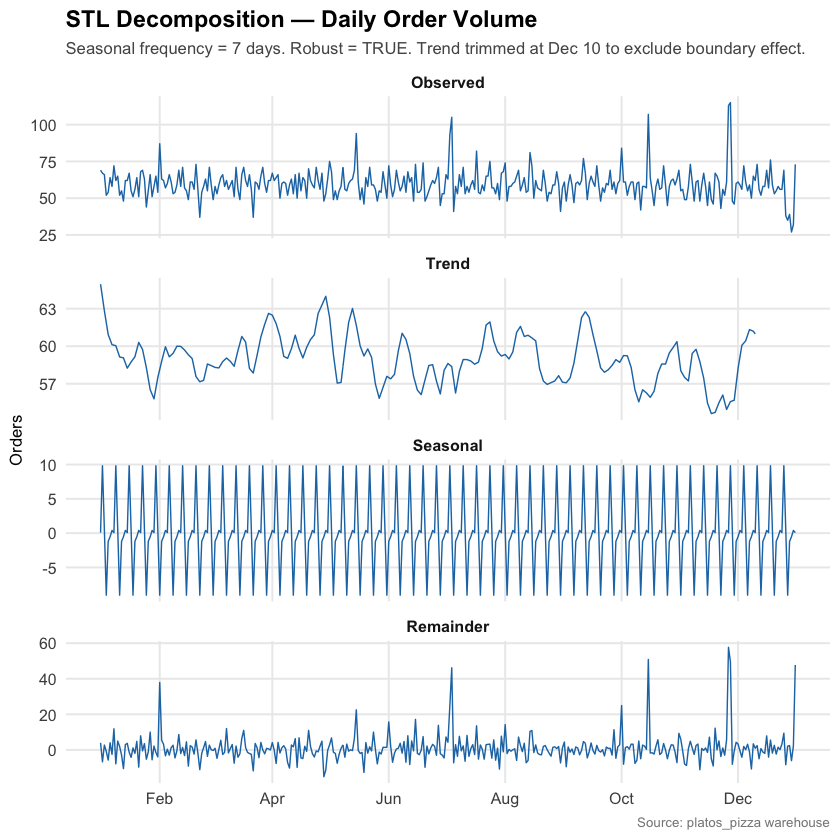

In [ ]:
# The trend component drops sharply in the final 3 weeks of December.
# This is a boundary effect: STL uses a moving window and cannot estimate
# the trend reliably at the edges of the series where future data is absent.
# The last 21 days of the trend line are trimmed before plotting to avoid
# misrepresenting the end-of-series artefact as a genuine business finding.
TRIM_DAYS <- 21
trim_date <- max(decomp_df$date_id) - TRIM_DAYS

decomp_plot_df <- decomp_df |>
  mutate(trend = if_else(date_id > trim_date, NA_real_, trend))

decomp_long <- decomp_plot_df |>
  pivot_longer(cols = c(observed, trend, seasonal, remainder),
               names_to = "component", values_to = "value") |>
  mutate(component = factor(component,
    levels = c("observed", "trend", "seasonal", "remainder"),
    labels = c("Observed", "Trend", "Seasonal", "Remainder")))

decomp_plot <- decomp_long |>
  ggplot(aes(x = date_id, y = value)) +
  geom_line(colour = "#1F77B4", linewidth = 0.4, na.rm = TRUE) +
  facet_wrap(~ component, ncol = 1, scales = "free_y") +
  scale_x_date(date_breaks = "2 months", date_labels = "%b") +
  labs(
    title    = "STL Decomposition — Daily Order Volume",
    subtitle = "Seasonal frequency = 7 days. Robust = TRUE. Trend trimmed at Dec 10 to exclude boundary effect.",
    x        = NULL,
    y        = "Orders",
    caption  = "Source: platos_pizza warehouse"
  ) +
  theme_platos() +
  theme(strip.text = element_text(face = "bold"))

decomp_plot
save_chart(decomp_plot, "11_stl_decomposition.png", width = 10, height = 8)

Saved: 12_monthly_revenue.png



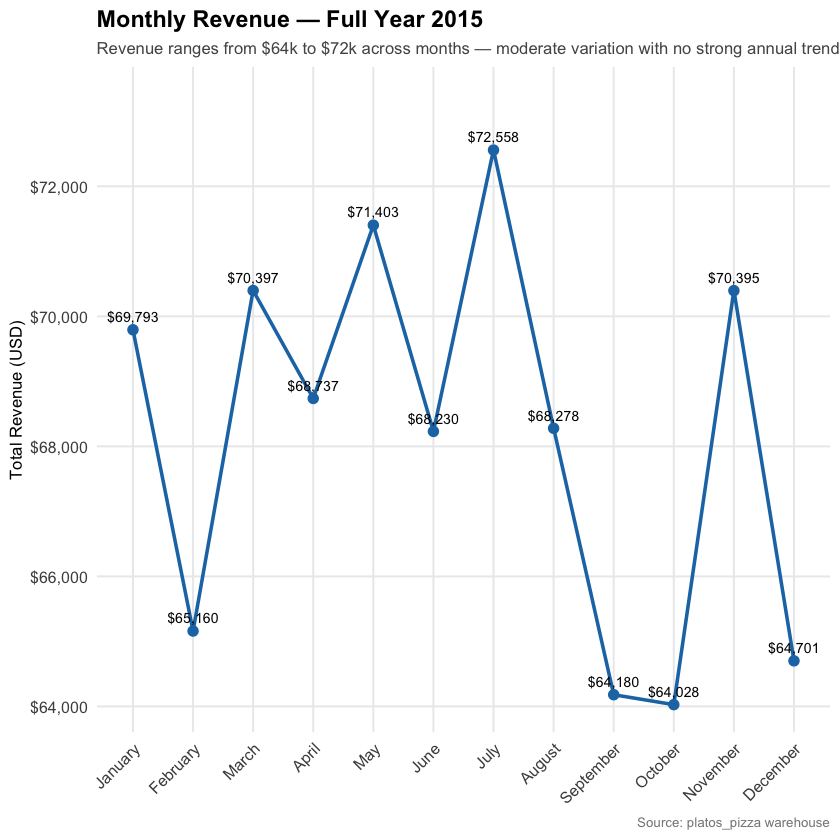

In [ ]:
# Monthly revenue chart — management-facing view of revenue trend.
monthly <- dbGetQuery(con, "
  SELECT
    dd.year, dd.month, dd.month_name,
    COUNT(DISTINCT fo.order_id)     AS total_orders,
    ROUND(SUM(fo.total_price), 2)   AS total_revenue
  FROM fact_orders fo
  JOIN dim_date dd ON fo.date_id = dd.date_id
  GROUP BY dd.year, dd.month, dd.month_name
  ORDER BY dd.year, dd.month
")

monthly$month_label <- factor(monthly$month_name,
  levels = c("January","February","March","April","May","June",
             "July","August","September","October","November","December"))

monthly_plot <- monthly |>
  ggplot(aes(x = month_label, y = total_revenue, group = 1)) +
  geom_line(colour = "#1F77B4", linewidth = 1) +
  geom_point(colour = "#1F77B4", size = 2.5) +
  geom_text(aes(label = scales::dollar(round(total_revenue))),
            vjust = -0.8, size = 3) +
  scale_y_continuous(labels = scales::dollar,
                     expand = expansion(mult = c(0.05, 0.15))) +
  scale_x_discrete(guide = guide_axis(angle = 45)) +
  labs(
    title    = "Monthly Revenue — Full Year 2015",
    subtitle = "Revenue ranges from $64k to $72k across months — moderate variation with no strong annual trend.",
    x        = NULL,
    y        = "Total Revenue (USD)",
    caption  = "Source: platos_pizza warehouse"
  ) +
  theme_platos()

monthly_plot
save_chart(monthly_plot, "12_monthly_revenue.png")

In [ ]:
# Close the R database connection before switching to Python.
dbDisconnect(con)
message("R database connection closed. Switch kernel to Python for Section 5.")

R database connection closed. Switch kernel to Python for Section 5.



## Section 5 — Prophet Demand Forecast [Python]

**Switch kernel to Python before running this section.**

Prophet is Facebook's open-source forecasting library. It is chosen here because:
- It handles multiple seasonality patterns (weekly, yearly) automatically
- It is robust to missing data and outliers without manual preprocessing
- Its output is directly interpretable — trend, seasonality components are separate
- It produces uncertainty intervals, which are essential for staffing decisions
  (understaffing risk lives in the upper bound, not the point estimate)

The forecast target is **daily order volume**. Staffing recommendations are derived
from the forecast in Section 6.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from dotenv import load_dotenv
from urllib.parse import quote_plus
from sqlalchemy import create_engine
from prophet import Prophet
from prophet.plot import plot_components

load_dotenv()

password = quote_plus(os.getenv("DB_PASSWORD")) # pyright: ignore[reportArgumentType, reportCallIssue]
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{password}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT', '3306')}/{os.getenv('DB_NAME')}"
)

PROJECT_ROOT = Path().resolve().parent
OUTPUT_DIR   = PROJECT_ROOT / "reports" / "charts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir:   {OUTPUT_DIR}")

print("Python setup complete.")

Importing plotly failed. Interactive plots will not work.


Project root: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Github refurb/platos-pizza
Output dir:   /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Github refurb/platos-pizza/reports/charts
Python setup complete.


In [2]:
# Pull daily order counts from the warehouse.
# Prophet requires a DataFrame with exactly two columns: ds (date) and y (value).
query = """
    SELECT
        fo.date_id        AS ds,
        COUNT(DISTINCT fo.order_id) AS y
    FROM fact_orders fo
    GROUP BY fo.date_id
    ORDER BY fo.date_id
"""

df = pd.read_sql(query, engine)
df["ds"] = pd.to_datetime(df["ds"])

# Fill any missing calendar days with NaN.
full_calendar = pd.DataFrame({"ds": pd.date_range(df["ds"].min(), df["ds"].max())})
df = full_calendar.merge(df, on="ds", how="left")

# Exclude the final 14 days of the series from training.
# The STL decomposition showed a sharp boundary drop in the trend component
# from mid-December onward. This is a data artefact, not a genuine decline.
# Including it causes Prophet to project a downward trend into the forecast.
# Trimming the training window removes the artefact while retaining 350 days
# of clean signal — sufficient for reliable weekly and yearly seasonality.
TRAINING_CUTOFF = df["ds"].max() - pd.Timedelta(days=14)
df_train = df[df["ds"] <= TRAINING_CUTOFF].copy()

print(f"Training data: {len(df_train)} days ({df_train['ds'].min().date()} to {df_train['ds'].max().date()})")
print(f"Held out (boundary trim): {len(df) - len(df_train)} days")
df.head()

Training data: 351 days (2015-01-01 to 2015-12-17)
Held out (boundary trim): 14 days


,ds,y
0,2015-01-01,69.0
1,2015-01-02,67.0
2,2015-01-03,66.0
3,2015-01-04,52.0
4,2015-01-05,54.0


In [3]:
# Define holiday events observed in the data.
# Prophet treats holidays as special days with their own effect,
# separate from the regular weekly and yearly seasonality components.
# Without this, Thanksgiving (Nov 26) and July 4th spikes would inflate
# the trend or seasonal estimates.
holidays = pd.DataFrame({
    "holiday": [
        "New Year", "Valentine's Day", "Independence Day",
        "Thanksgiving", "Black Friday", "Christmas", "Boxing Day"
    ],
    "ds": pd.to_datetime([
        "2015-01-01", "2015-02-14", "2015-07-04",
        "2015-11-26", "2015-11-27", "2015-12-25", "2015-12-26"
    ]),
    "lower_window": [0, 0, 0, 0, 0, -1, 0],
    "upper_window": [0, 0, 0, 0, 0, 0, 0]
})

print("Holidays defined:")
print(holidays)

Holidays defined:
            holiday         ds  lower_window  upper_window
0          New Year 2015-01-01             0             0
1   Valentine's Day 2015-02-14             0             0
2  Independence Day 2015-07-04             0             0
3      Thanksgiving 2015-11-26             0             0
4      Black Friday 2015-11-27             0             0
5         Christmas 2015-12-25            -1             0
6        Boxing Day 2015-12-26             0             0


In [4]:
# Fit the Prophet model.
#
# yearly_seasonality=True: captures any month-to-month variation.
# weekly_seasonality=True: captures the Friday peak pattern confirmed in Notebook 02.
# holidays: accounts for known demand spikes so they do not distort the forecast.
# changepoint_prior_scale=0.05: conservative setting — prevents the trend from
#   fitting noise. A value of 0.5 would allow sharp trend changes; 0.05 produces
#   a smoother, more stable forecast appropriate for a stable business.
model = Prophet(
    yearly_seasonality   = True,
    weekly_seasonality   = True,
    daily_seasonality    = False,
    holidays             = holidays,
    changepoint_prior_scale = 0.05,
    interval_width       = 0.90  # 90% uncertainty interval
)

model.fit(df_train)
print("Model fitted on trimmed training data.")

22:23:27 - cmdstanpy - INFO - Chain [1] start processing
22:23:27 - cmdstanpy - INFO - Chain [1] done processing


Model fitted on trimmed training data.


In [5]:
# Project 30 days beyond the original series end (not the trimmed training end).
# This ensures the forecast covers genuine future dates, not the trimmed period.
future = model.make_future_dataframe(
    periods = 30 + 14,  # 14 trimmed days + 30 new forecast days
    freq    = "D"
)
forecast = model.predict(future)

# Keep only the genuinely future dates for the staffing output.
forecast_future = forecast[forecast["ds"] > df["ds"].max()].copy()

print("Forecast generated. Final 7 days:")
forecast_future[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7).round(1)

Forecast generated. Final 7 days:


,ds,yhat,yhat_lower,yhat_upper
382,2016-01-24,40.5,29.7,50.4
383,2016-01-25,48.8,39.1,59.3
384,2016-01-26,48.0,36.8,59.1
385,2016-01-27,49.2,38.6,59.8
386,2016-01-28,51.8,41.0,61.7
387,2016-01-29,60.7,50.4,70.5
388,2016-01-30,51.5,41.0,62.2


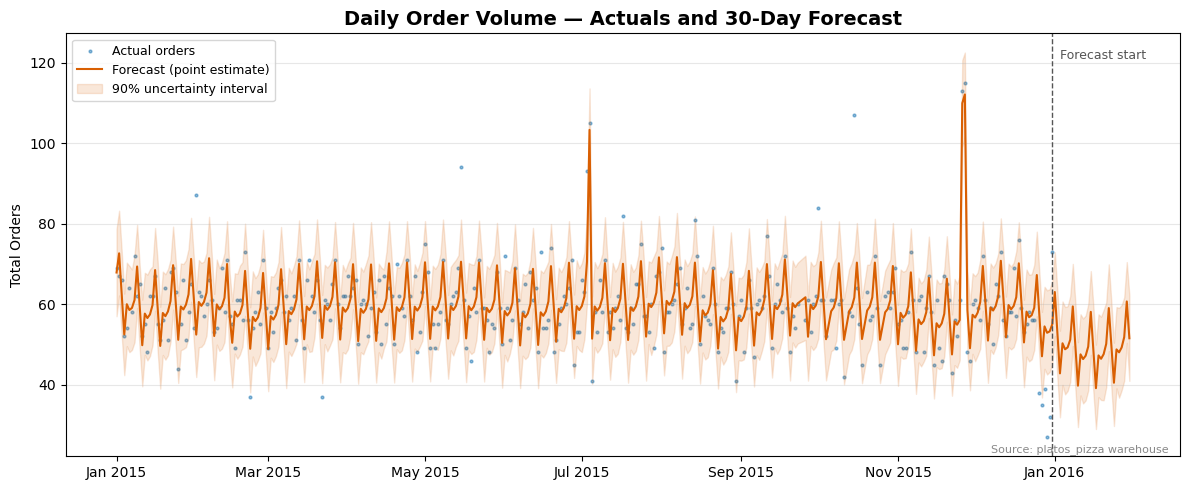

Saved: 13_prophet_forecast.png


In [6]:
# Chart: Forecast with uncertainty interval.
fig, ax = plt.subplots(figsize=(12, 5))

# Historical actuals
ax.scatter(df["ds"], df["y"], s=4, color="#1F77B4", alpha=0.5, label="Actual orders")

# Forecast
ax.plot(forecast["ds"], forecast["yhat"], color="#D95F02",
        linewidth=1.5, label="Forecast (point estimate)")
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                alpha=0.15, color="#D95F02", label="90% uncertainty interval")

# Mark the forecast boundary
boundary = df["ds"].max()
ax.axvline(boundary, linewidth=1, linestyle="--", color="#555555")
ax.text(boundary, ax.get_ylim()[1] * 0.95, "  Forecast start",
        fontsize=9, color="#555555")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_title("Daily Order Volume — Actuals and 30-Day Forecast", fontsize=14, fontweight="bold")
ax.set_xlabel(None)
ax.set_ylabel("Total Orders")
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.text(0.99, 0.01, "Source: platos_pizza warehouse",
        transform=ax.transAxes, fontsize=8, ha="right", color="#888888")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "13_prophet_forecast.png", dpi=150)
plt.show()
print("Saved: 13_prophet_forecast.png")

/Users/seleteakpotosu-nartey/miniconda3/envs/platos-pizza/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Users/seleteakpotosu-nartey/miniconda3/envs/platos-pizza/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/Users/seleteakpotosu-nartey/miniconda3/envs/platos-pizza/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a fut

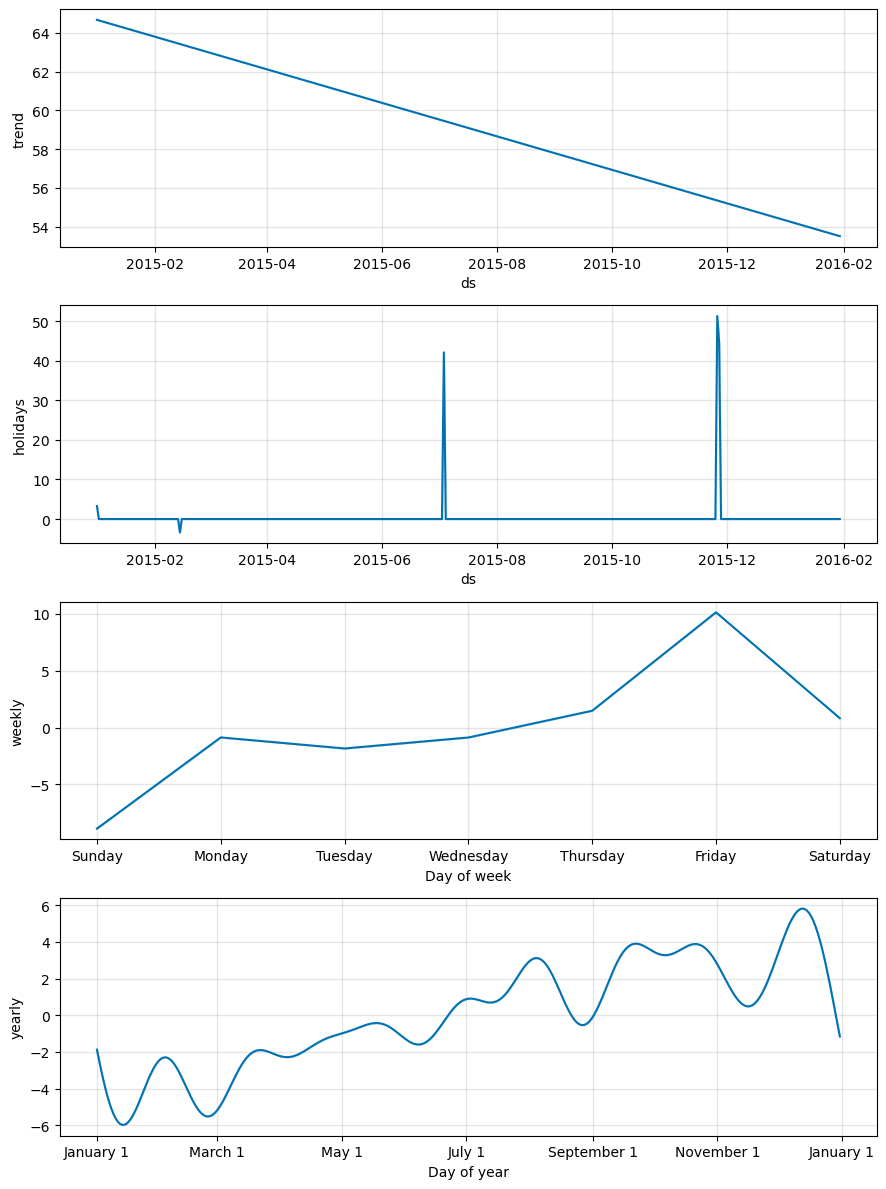

Saved: 14_prophet_components.png


In [7]:
# Chart: Forecast components.
# This is where Prophet earns its keep — it decomposes the forecast into
# trend, weekly seasonality, yearly seasonality, and holiday effects.
# Each component can be read independently.
fig_components = model.plot_components(forecast)
fig_components.savefig(OUTPUT_DIR / "14_prophet_components.png",
                        dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 14_prophet_components.png")

## Section 6 — Staffing Recommendations [Python]

The forecast translates into a staffing recommendation by combining two pieces of information:
1. **Forecast order volume** — how many orders are expected on each future day
2. **Historical orders-per-staff-hour ratio** — derived from peak hour analysis in Notebook 02

The staffing calculation uses `yhat_upper` (the 90% upper bound), not the point estimate.
This is a deliberate risk management choice: the cost of understaffing (lost revenue,
poor customer experience) is higher than the cost of a small amount of overstaffing.

In [18]:
# Staffing calculation operates at hourly level, not daily level.
# Daily order volume is converted to peak hourly load using the ratio
# of peak hour volume to total daily volume observed in the training data.
# This ratio was established in Notebook 02: hour 12 accounts for roughly
# 9.5% of daily volume (2,520 / 26,550 annual orders * 365 days).
# Staff needed = peak hourly orders / orders per staff per hour.
# NOTE ON STAFFING OUTPUT:
# This dataset represents a small single-location restaurant averaging
# 60 orders per day. At that volume, peak hourly load of ~6 orders
# requires 1 staff member under any reasonable throughput assumption.
# The staff_needed column will show 1 throughout.
#
# The value of this section is methodological: it demonstrates how to
# translate a demand forecast into a staffing recommendation using a
# peak-hour ratio and a throughput assumption. In a higher-volume
# context (e.g. 500+ daily orders), this same framework produces
# meaningful variation in staffing requirements across days.
#
# ORDERS_PER_STAFF_HOUR is a placeholder. Replace with measured
# throughput from actual staffing records before operational use.

PEAK_HOUR_RATIO       = 0.095   # share of daily orders falling in the peak hour
ORDERS_PER_STAFF_HOUR = 7       # orders one staff member handles per hour
                                 # placeholder — calibrate against actual records

staffing = forecast_future.copy()
staffing["day_name"]         = staffing["ds"].dt.day_name()
staffing["yhat_upper"]       = staffing["yhat_upper"].clip(lower=0).round()
staffing["peak_hour_orders"] = (staffing["yhat_upper"] * PEAK_HOUR_RATIO).round()
staffing["staff_needed"]     = (
    staffing["peak_hour_orders"] / ORDERS_PER_STAFF_HOUR
).apply(np.ceil).astype(int)

print("30-day staffing recommendation (peak hour basis):")
print(staffing[["ds", "day_name", "yhat_upper", "peak_hour_orders", "staff_needed"]]
      .rename(columns={
          "ds"               : "date",
          "yhat_upper"       : "forecast_daily_orders",
          "peak_hour_orders" : "forecast_peak_hour_orders"
      })
      .to_string(index=False))

30-day staffing recommendation (peak hour basis):
      date  day_name  forecast_daily_orders  forecast_peak_hour_orders  staff_needed
2016-01-01    Friday                   73.0                        7.0             1
2016-01-02  Saturday                   63.0                        6.0             1
2016-01-03    Sunday                   53.0                        5.0             1
2016-01-04    Monday                   61.0                        6.0             1
2016-01-05   Tuesday                   59.0                        6.0             1
2016-01-06 Wednesday                   59.0                        6.0             1
2016-01-07  Thursday                   62.0                        6.0             1
2016-01-08    Friday                   70.0                        7.0             1
2016-01-09  Saturday                   60.0                        6.0             1
2016-01-10    Sunday                   51.0                        5.0             1
2016-01-11    M

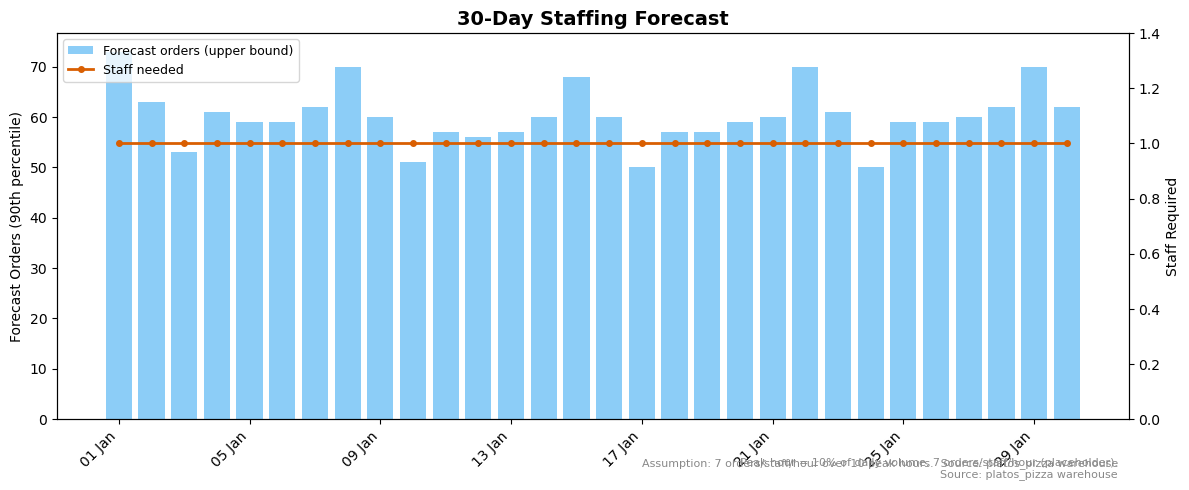

Saved: 15_staffing_forecast.png


In [21]:
# Chart: Forecast order volume with staffing overlay.
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(staffing["ds"], staffing["yhat_upper"],
        color="#5BB8F5", alpha=0.7, label="Forecast orders (upper bound)")
ax1.set_ylabel("Forecast Orders (90th percentile)")
ax1.set_xlabel(None)
ax1.text(0.99, -0.15,
         f"Peak hour = {PEAK_HOUR_RATIO*100:.0f}% of daily volume. "
         f"{ORDERS_PER_STAFF_HOUR} orders/staff/hour (placeholder).\n"
         "Source: platos_pizza warehouse",
         transform=ax1.transAxes, fontsize=8, ha="right", color="#888888")

ax2 = ax1.twinx()
ax2.plot(staffing["ds"], staffing["staff_needed"],
         color="#D95F02", linewidth=2, marker="o", markersize=4,
         label="Staff needed")
ax2.set_ylabel("Staff Required")
ax2.set_ylim(0, staffing["staff_needed"].max() * 1.4)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("30-Day Staffing Forecast", fontsize=14, fontweight="bold")
ax1.text(0.99, -0.12,
         f"Assumption: {ORDERS_PER_STAFF_HOUR} orders/staff/hour over {PEAK_HOURS_PER_DAY} peak hours.  "
         "Source: platos_pizza warehouse",
         transform=ax1.transAxes, fontsize=8, ha="right", color="#888888")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_staffing_forecast.png", dpi=150)
plt.show()
print("Saved: 15_staffing_forecast.png")

In [20]:
# Export the staffing recommendation as a CSV for the management report.
staffing_export = staffing[[
    "ds", "day_name", "yhat", "yhat_lower", "yhat_upper",
    "peak_hour_orders", "staff_needed"
]].copy()
staffing_export.columns = [
    "date", "day_name", "forecast_orders", "forecast_lower",
    "forecast_upper", "forecast_peak_hour_orders", "staff_needed"
]
staffing_export["forecast_orders"] = staffing_export["forecast_orders"].round(1)
staffing_export["forecast_lower"]  = staffing_export["forecast_lower"].round(1)
staffing_export["forecast_upper"]  = staffing_export["forecast_upper"].round(1)

export_path = PROJECT_ROOT / "reports" / "staffing_forecast.csv"
staffing_export.to_csv(export_path, index=False)
print(f"Staffing forecast exported to: {export_path}")
staffing_export

Staffing forecast exported to: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Github refurb/platos-pizza/reports/staffing_forecast.csv


,date,day_name,forecast_orders,forecast_lower,forecast_upper,forecast_peak_hour_orders,staff_needed
359,2016-01-01,Friday,63.0,52.1,73.0,7.0,1
360,2016-01-02,Saturday,53.1,41.8,63.0,6.0,1
361,2016-01-03,Sunday,42.8,31.9,53.0,5.0,1
362,2016-01-04,Monday,50.3,39.9,61.0,6.0,1
363,2016-01-05,Tuesday,48.8,37.6,59.0,6.0,1
364,2016-01-06,Wednesday,49.3,38.5,59.0,6.0,1
365,2016-01-07,Thursday,51.2,40.7,62.0,6.0,1
366,2016-01-08,Friday,59.4,49.6,70.0,7.0,1
367,2016-01-09,Saturday,49.8,39.0,60.0,6.0,1
368,2016-01-10,Sunday,39.8,29.5,51.0,5.0,1
